In [3]:
import numpy as np
import matplotlib.pyplot as plt
from os.path import join

In [30]:
def getrdmaarray(perm):
    # perm = "NoPerm"
    # perm = "RandomPerm"
    # perm = "METISvwgtfile"
    abspath = "/pscratch/sd/y/yuxihong/graphclustering/perfrun/"
    dataset = "nlpkkt200"
    gentype = 5
    mpiconfig='64mpi_8omp'
    nprocs = 64
    f"rdmacallsDataset{dataset}_{mpiconfig}_{perm}_AA1d.bin"
    rdmacallfile = join(abspath,f"rdmacallsDataset{dataset}_{mpiconfig}_{perm}_AA1d.bin")
    rdmacalls = np.fromfile(rdmacallfile,dtype=np.int32)
    rdmacalls = rdmacalls.reshape((-1,nprocs))
    rdmamemfile = join(abspath,f"rdmamemsDataset{dataset}_{mpiconfig}_{perm}_AA1d.bin")
    rdmamems = np.fromfile(rdmamemfile,dtype=np.float64)
    rdmamems = rdmamems.reshape((-1,nprocs))
    rdmatimefile = join(abspath,f"rdmatimesDataset{dataset}_{mpiconfig}_{perm}_AA1d.bin")
    rdmatimes = np.fromfile(rdmatimefile,dtype=np.float64)
    rdmatimes = rdmatimes.reshape((-1,nprocs))
    # write to file 
    with open(f"rdmacalls_nprocs{nprocs}_dataset{dataset}_gentype{gentype}_{perm}.txt", 'w') as f:
        f.write(f"RDMA Call Number Analysis, Dataset:{dataset}, gentype{gentype}, nprocs{nprocs} Source is Row, Target is Column\n")
        np.savetxt(f,rdmacalls,fmt="%6d")
        f.write(f"\n\nMemory Requirement Analysis, Dataset:{dataset}, gentype{gentype}, nprocs{nprocs} Source is Row, Target is Column\n")
        np.savetxt(f,rdmamems,fmt="%7.2f")
        f.write(f"\n\nRDMA Time Analysis (unit: seconds), Dataset:{dataset}, gentype{gentype}, nprocs{nprocs} Source is Row, Target is Column\n")
        np.savetxt(f,rdmatimes,fmt="%7.3f")
    return rdmacalls,rdmamems,rdmatimes

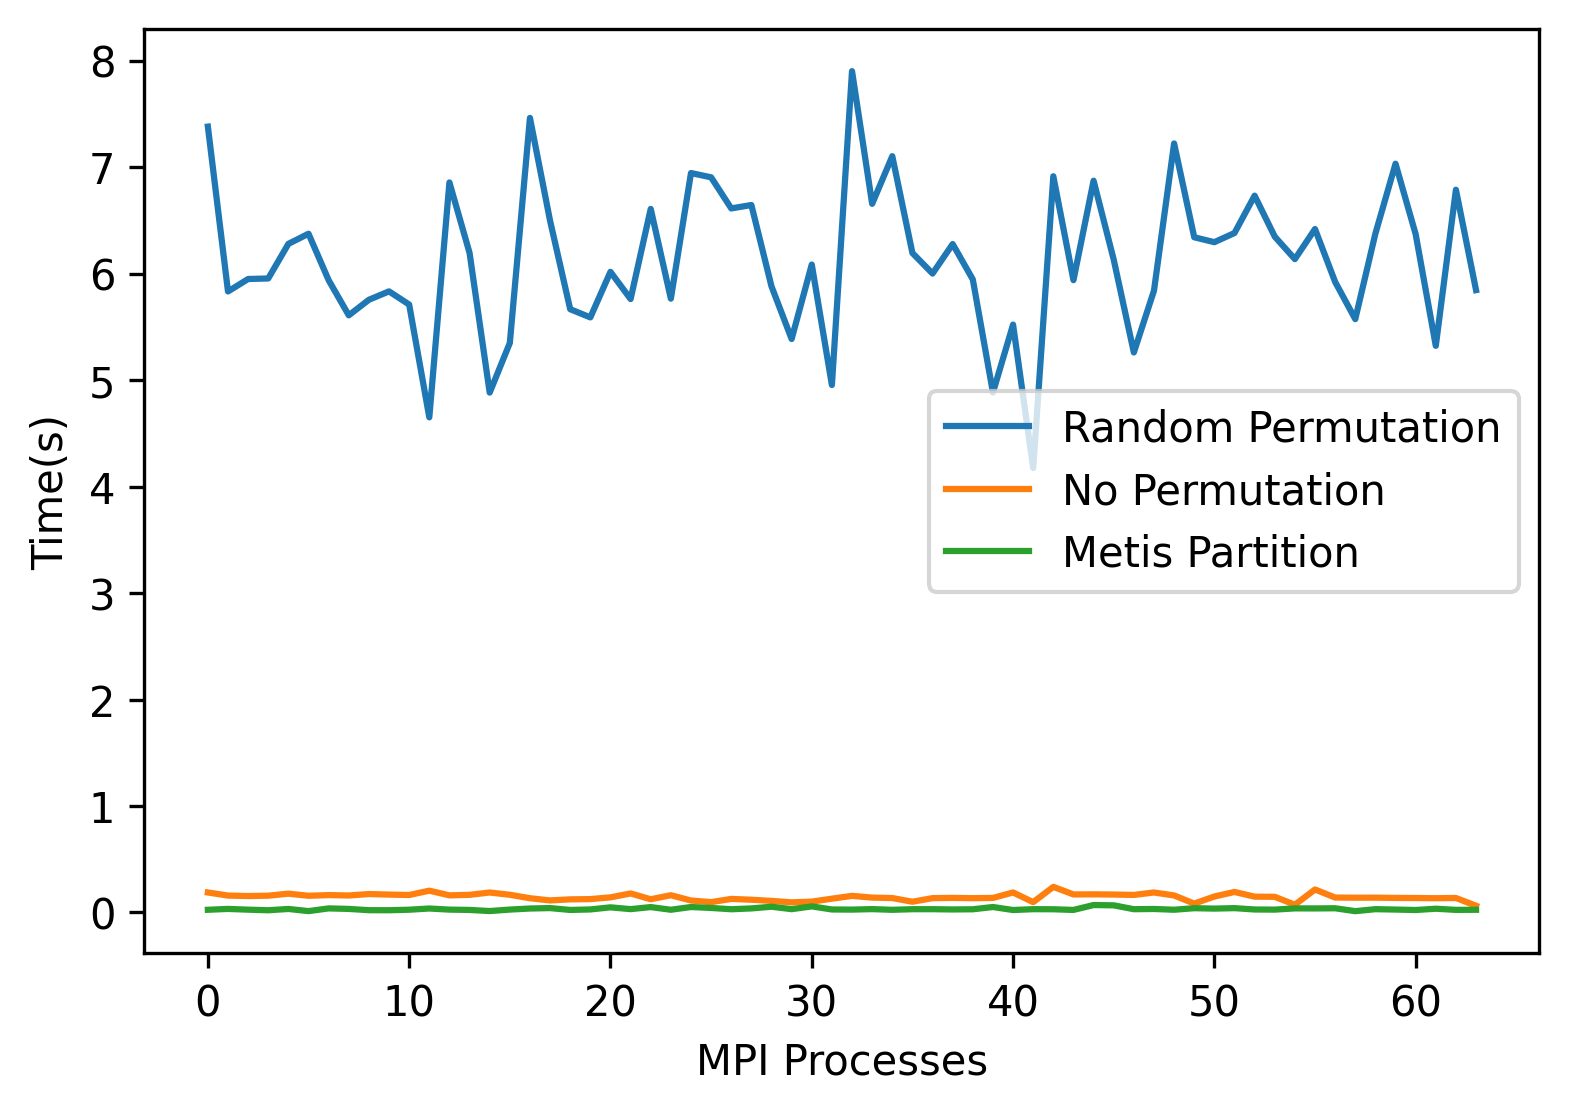

In [31]:
plt.figure(figsize=(6,4),dpi=300)
rdmacalls,rdmamems,rdmatimes = getrdmaarray("RandomPerm")
aggtimepermpi = np.sum(rdmatimes,axis=0)
plt.plot(aggtimepermpi,label="Random Permutation")
rdmacalls,rdmamems,rdmatimes = getrdmaarray("NoPerm")
aggtimepermpi = np.sum(rdmatimes,axis=0)
plt.plot(aggtimepermpi,label="No Permutation")
rdmacalls,rdmamems,rdmatimes = getrdmaarray("METISvwgtfile")
aggtimepermpi = np.sum(rdmatimes,axis=0)
plt.plot(aggtimepermpi,label="Metis Partition")
plt.ylabel("Time(s)")
plt.xlabel("MPI Processes")
plt.legend()
plt.show()

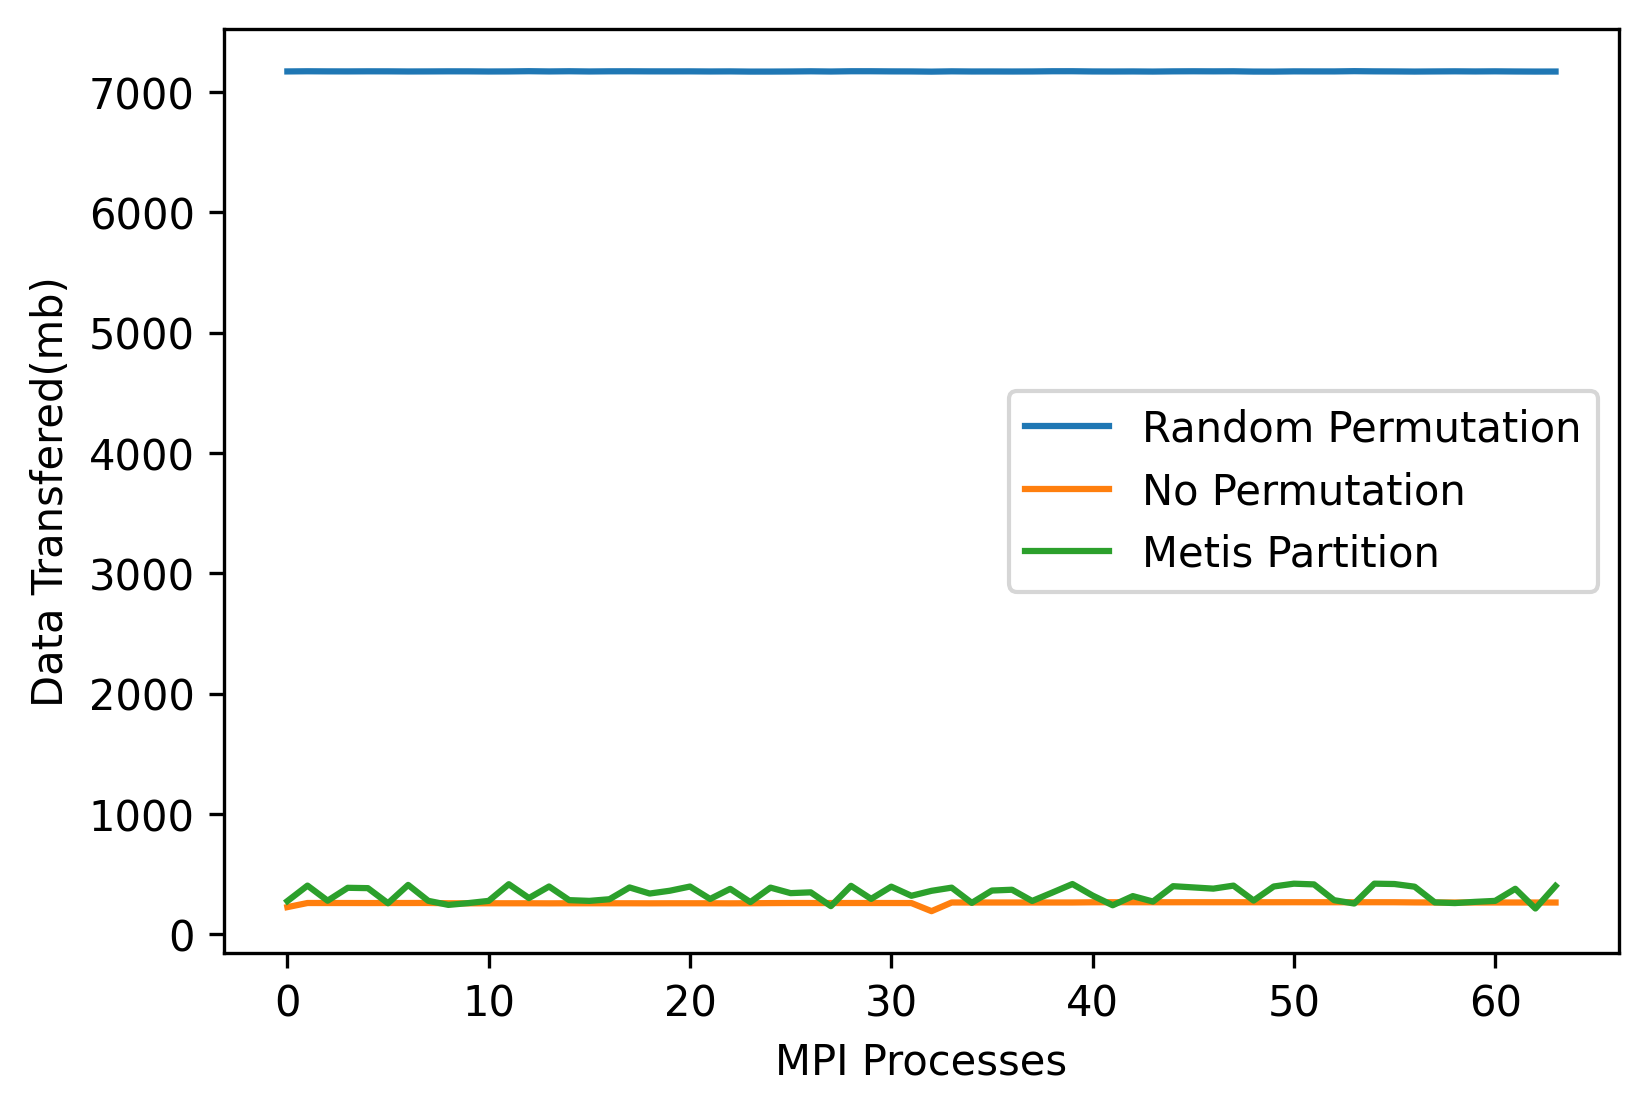

In [33]:
plt.figure(figsize=(6,4),dpi=300)
rdmacalls,rdmamems,rdmatimes = getrdmaarray("RandomPerm")
aggtimepermpi = np.sum(rdmamems,axis=0)
plt.plot(aggtimepermpi,label="Random Permutation")
rdmacalls,rdmamems,rdmatimes = getrdmaarray("NoPerm")
aggtimepermpi = np.sum(rdmamems,axis=0)
plt.plot(aggtimepermpi,label="No Permutation")
rdmacalls,rdmamems,rdmatimes = getrdmaarray("METISvwgtfile")
aggtimepermpi = np.sum(rdmamems,axis=0)
plt.plot(aggtimepermpi,label="Metis Partition")
plt.ylabel("Data Transfered(mb)")
plt.xlabel("MPI Processes")
plt.legend()
plt.show()

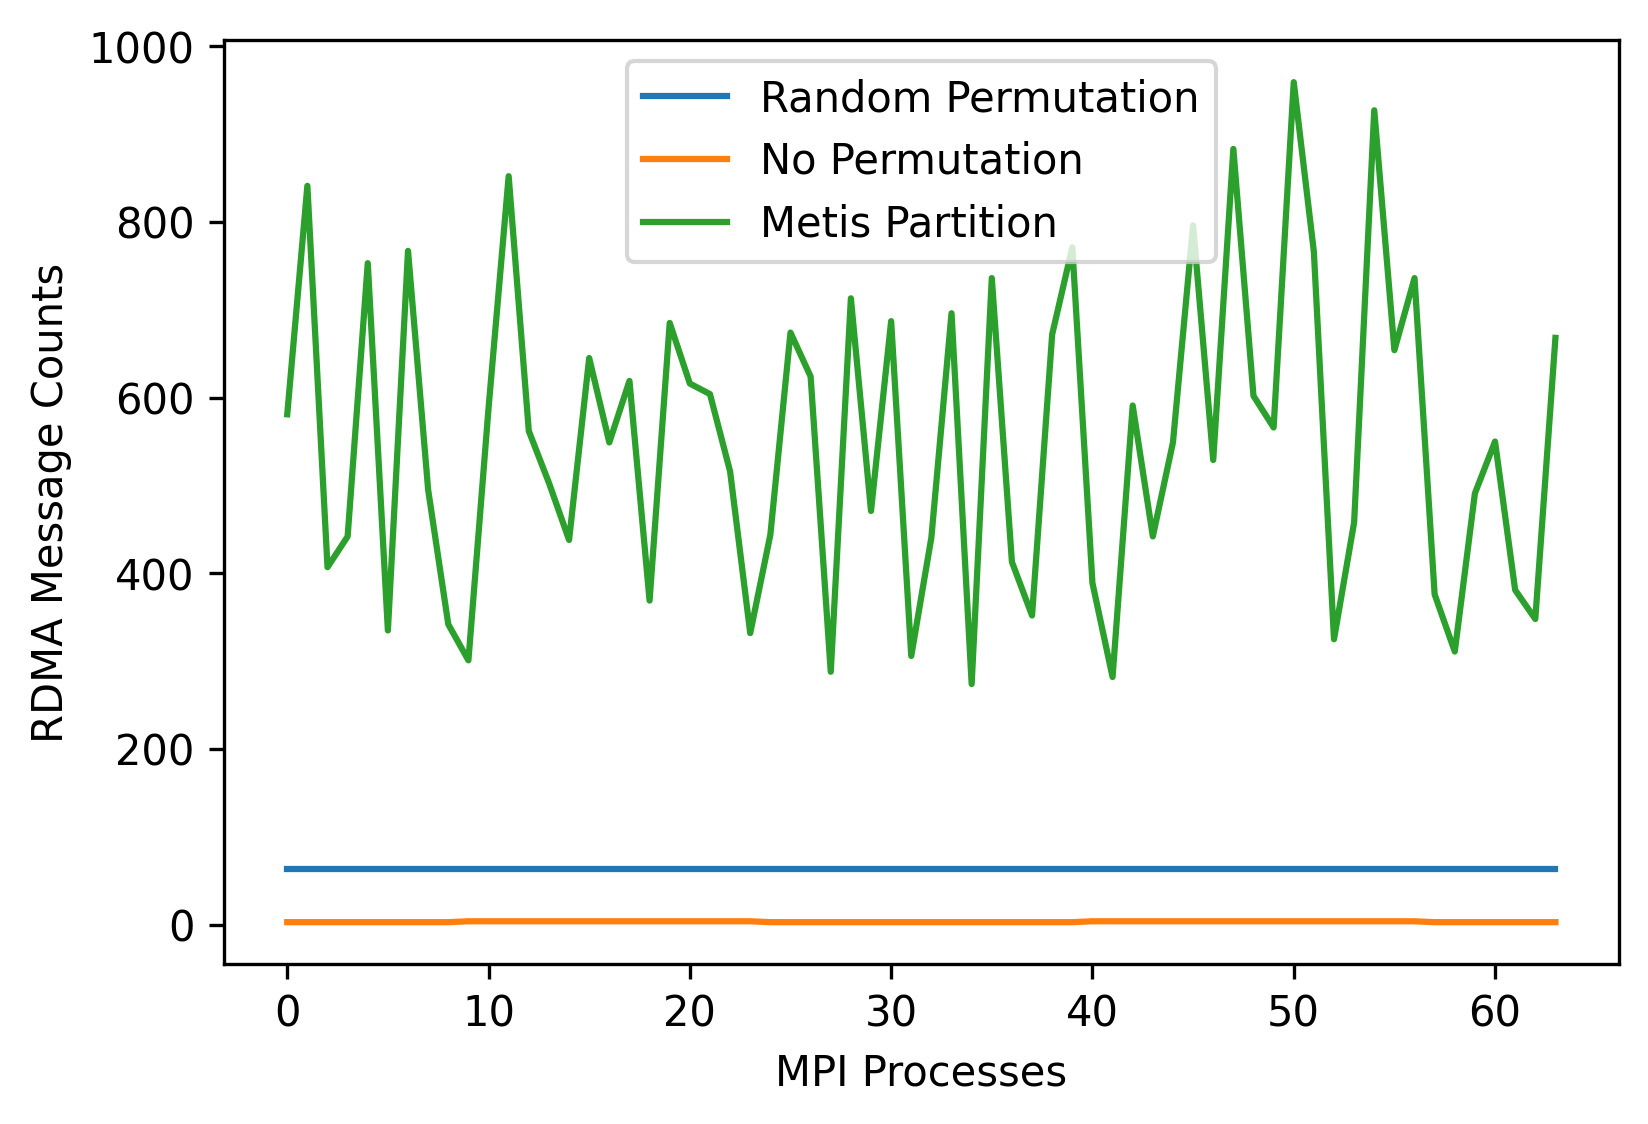

In [34]:
plt.figure(figsize=(6,4),dpi=300)
rdmacalls,rdmamems,rdmatimes = getrdmaarray("RandomPerm")
aggtimepermpi = np.sum(rdmacalls,axis=0)
plt.plot(aggtimepermpi,label="Random Permutation")
rdmacalls,rdmamems,rdmatimes = getrdmaarray("NoPerm")
aggtimepermpi = np.sum(rdmacalls,axis=0)
plt.plot(aggtimepermpi,label="No Permutation")
rdmacalls,rdmamems,rdmatimes = getrdmaarray("METISvwgtfile")
aggtimepermpi = np.sum(rdmacalls,axis=0)
plt.plot(aggtimepermpi,label="Metis Partition")
plt.ylabel("RDMA Message Counts")
plt.xlabel("MPI Processes")
plt.legend()
plt.show()